![Banner](../../images/02_banner.png)


# 2.3 Visualisation and Exploratory Analysis

**Part:** 2 — Spatial Autocorrelation (Chapter 2.3 of 6)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** Choropleth classification, the Moran scatterplot, and reading spatial patterns before testing them

**Library:** `spatialstats.viz`, `spatialstats.esda` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Choropleth Classification Schemes](#3.-Choropleth-Classification-Schemes)

4. [The Moran Scatterplot](#4.-The-Moran-Scatterplot)

   - 4.1 [A labelling caveat: centred, not standardised](#4.1-A-labelling-caveat:-centred,-not-standardised)

   - 4.2 [The island on the axis](#4.2-The-island-on-the-axis)

5. [Reading the Quadrants for a Health Outcome](#5.-Reading-the-Quadrants-for-a-Health-Outcome)

6. [High-leverage Points](#6.-High-leverage-Points)

7. [Summary and Conclusions](#7.-Summary-and-Conclusions)

8. [Resources](#8.-Resources)


***
## 1. Overview

Chapter 2.1 looked at a raw choropleth and judged "yes, this looks clustered" by eye. This chapter makes that
judgement more systematic, in two steps, before Chapter 2.4 turns it into a formal test:

| Step | What we do |
|------|------------|
| Classification | Compare three ways of binning a continuous variable into a choropleth's colour classes, and how the choice changes the map's visual message |
| Moran scatterplot | Plot each county's (centred) value against its spatial lag — the geometric object that Moran's I actually summarises as a single slope |
| Quadrants | Read HH / LL / HL / LH in terms of the health outcome, and what each quadrant suggests for intervention |
| Caveats | Two real quirks of this library's implementation: a mislabelled axis, and where the one island in the data lands |

By the end, the Moran scatterplot built here is the same object Chapter 2.5 revisits pointwise, county by
county, as the Local Moran's I (LISA) statistic.

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.esda import Moran
from spatialstats.viz import choropleth, moran_scatter

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(counties)
print(f"spatialstats : version {spatialstats.__version__}")
print(f"counties     : {counties.shape[0]}, W islands: {len(w.islands())}")

spatialstats : version 0.2.0
counties     : 217, W islands: 1


***
## 3. Choropleth Classification Schemes

A choropleth needs to bin a continuous variable into a small number of colour classes. `spatialstats.viz.choropleth`
offers three schemes (delegating to `mapclassify` when installed): **quantiles** (equal *count* per class),
**equal interval** (equal *value width* per class), and **natural breaks / Fisher–Jenks** (classes chosen to
minimise within-class variance).

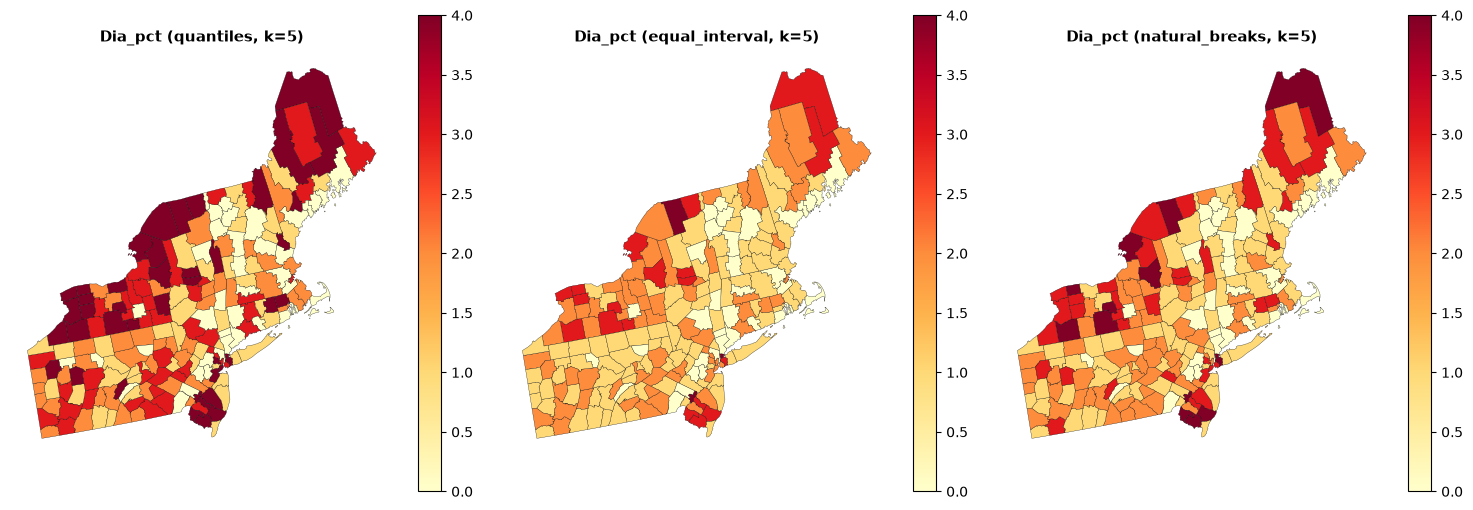

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, scheme in zip(axes, ["quantiles", "equal_interval", "natural_breaks"]):
    choropleth(counties, "Dia_pct", scheme=scheme, k=5, ax=ax, cmap="YlOrRd")
plt.tight_layout()
plt.show()

In [3]:
import mapclassify
for scheme, cls in [("Quantiles", mapclassify.Quantiles(counties["Dia_pct"], k=5)),
                     ("Equal interval", mapclassify.EqualInterval(counties["Dia_pct"], k=5)),
                     ("Natural breaks", mapclassify.FisherJenks(counties["Dia_pct"], k=5))]:
    counts = pd.Series(cls.yb).value_counts().sort_index()
    print(f"{scheme:16s} bin edges: {np.round(cls.bins, 2)}  |  counties per class: {counts.tolist()}")

Quantiles        bin edges: [ 7.24  7.87  8.48  9.32 12.44]  |  counties per class: [44, 43, 43, 44, 43]
Equal interval   bin edges: [ 7.18  8.49  9.81 11.12 12.44]  |  counties per class: [40, 90, 65, 19, 3]
Natural breaks   bin edges: [ 7.14  8.14  9.08 10.16 12.44]  |  counties per class: [38, 71, 60, 34, 14]


Quantiles always give five *visually similar-sized* colour patches (43–44 counties each) regardless of how the
underlying values are distributed — good for showing rank, poor for showing magnitude gaps. Equal-interval
classes are easy to interpret ("each class spans about 1.3 percentage points") but can leave some classes nearly
empty if the data are skewed. Natural breaks looks for real gaps in the data and tends to isolate genuine
outliers into their own class. None of the three is "correct" — they answer different questions, and switching
schemes is often enough to change which counties look like the extreme ones on the map.

***
## 4. The Moran Scatterplot

Moran's I (formally defined in Chapter 2.4) has a geometric interpretation: it is the slope of the best-fit
line through a scatterplot of each region's value against the (row-standardised) average of its neighbours —
the **spatial lag**. `moran_scatter` builds this plot directly from a `MoranResult` (or from raw `y, w`).

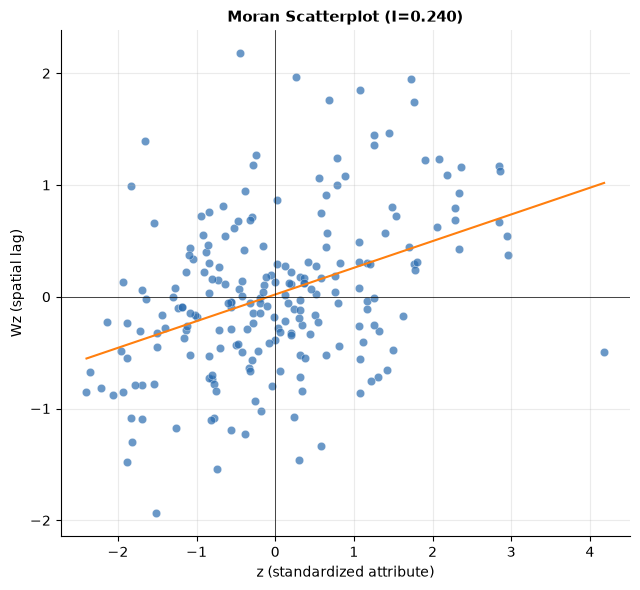

Moran's I (the fitted slope) = 0.2398


In [4]:
res = Moran(counties["Dia_pct"], w, permutations=999, seed=1)
fig, ax = plt.subplots(figsize=(6.5, 6))
moran_scatter(res, ax=ax, color=C["blue"], alpha=0.7, edgecolor="white", linewidth=0.3)
plt.tight_layout()
plt.show()
print(f"Moran's I (the fitted slope) = {res.I:.4f}")

### 4.1 A labelling caveat: centred, not standardised

The scatterplot's axis labels ("z (standardized attribute)") describe the *x*-axis as standardised, but the
implementation only **centres** the variable (subtracts the mean) — it does not divide by the standard
deviation. This is a real, checkable discrepancy between the label and the code:

In [5]:
import inspect
from spatialstats.viz.moran import moran_scatter as _ms
src_line = [l for l in inspect.getsource(_ms).splitlines() if "z = y - y.mean()" in l][0]
print("moran_scatter source line:", src_line.strip())
print(f"std(z) as actually plotted: {(counties['Dia_pct'] - counties['Dia_pct'].mean()).std():.4f}  (not 1.0)")

moran_scatter source line: z = y - y.mean()
std(z) as actually plotted: 1.2018  (not 1.0)


The consequence is cosmetic, not statistical: Moran's I itself (the slope) is invariant to this scaling choice,
so the *number* reported is unaffected. What changes is the axis units — the horizontal spread in the figure
above is in percentage points of diabetes prevalence, not in standard-deviation units as the label implies. When
reporting this plot, relabel the axis as "centred attribute" or divide by `z.std()` before plotting if a true
z-score axis is wanted.

### 4.2 The island on the axis

Nantucket County (Chapter 2.2, Section 9) has zero Queen neighbours, so its row-standardised spatial lag is
exactly $0$ by construction — every island sits exactly on the horizontal axis of this plot, regardless of its
own value.

In [6]:
z_all = counties["Dia_pct"].to_numpy() - counties["Dia_pct"].mean()
lag_all = w.lag(z_all)
island_idx = w.islands()[0]
print(f"Nantucket: z = {z_all[island_idx]:.3f}, lag = {lag_all[island_idx]:.6f}")

on_axis = np.isclose(lag_all, 0.0)
print(f"counties with lag exactly 0 (islands only): {on_axis.sum()} -> {counties.loc[on_axis, 'COUNTY'].tolist()}")

Nantucket: z = -1.299, lag = 0.000000
counties with lag exactly 0 (islands only): 1 -> ['Nantucket County']


A county with lag exactly $0$ contributes nothing to the slope in either the "high" or "low" neighbourhood
direction — it is neither confirmed nor contradicted by its (non-existent) neighbours. Section 5's quadrant
count below correctly excludes it from all four quadrants rather than assigning it arbitrarily.

***
## 5. Reading the Quadrants for a Health Outcome

The Moran scatterplot splits into four quadrants around the origin, and for a health-outcome variable like
`Dia_pct` each has a distinct, actionable reading:

| Quadrant | Condition | Reading for `Dia_pct` |
|---|---|---|
| **HH** (high-high) | above-average county, above-average neighbours | A high-prevalence *region* — supports a regional public-health intervention, not a single-county one |
| **LL** (low-low) | below-average county, below-average neighbours | A low-prevalence region — a candidate for understanding protective regional factors |
| **HL** (high-low) | above-average county surrounded by below-average neighbours | A local outlier — investigate a county-specific cause (access to care, local demographics) or a data-quality issue |
| **LH** (low-high) | below-average county surrounded by above-average neighbours | A possibly protective pocket within a high-prevalence region — worth understanding what is different locally |

In [7]:
quad_names = np.full(len(z_all), "on-axis (island)", dtype=object)
quad_names[(z_all > 0) & (lag_all > 0)] = "HH"
quad_names[(z_all < 0) & (lag_all < 0)] = "LL"
quad_names[(z_all > 0) & (lag_all < 0)] = "HL"
quad_names[(z_all < 0) & (lag_all > 0)] = "LH"
counts = pd.Series(quad_names).value_counts()
counts

LL                  72
HH                  62
HL                  41
LH                  41
on-axis (island)     1
Name: count, dtype: int64

The clear majority of counties fall in the self-reinforcing HH/LL quadrants (62 + 72 = 134 of 217, 62%), which
is exactly what a positive, significant Moran's I predicts — but the plot also flags 41 HL and 41 LH counties
whose *local* story runs against their region. Chapter 2.5 gives each of those counties a formal significance
test (most will turn out to be indistinguishable from noise); for now, the scatterplot is a map of candidates
for closer inspection, not a list of confirmed local outliers.

***
## 6. High-leverage Points

Like any regression slope, Moran's I can be pulled by a small number of extreme observations. A quick check:
which counties have the largest `|z|` (most extreme prevalence), and do they sit consistently with the overall
positive slope or against it?

In [8]:
leverage = pd.DataFrame({
    "COUNTY": counties["COUNTY"], "STATE": counties["STATE"],
    "Dia_pct": counties["Dia_pct"], "z": z_all, "lag": lag_all, "quadrant": quad_names,
}).reindex(np.argsort(-np.abs(z_all))[:8])
leverage

,COUNTY,STATE,Dia_pct,z,lag,quadrant
71,Bronx County,New York,12.44,4.18106,-0.491440,HL
181,Philadelphia County,Pennsylvania,11.22,2.96106,0.371060,HH
85,Franklin County,New York,11.20,2.94106,0.541060,HH
105,Orleans County,New York,11.12,2.86106,1.127727,HH
64,Salem County,New Jersey,11.11,2.85106,1.171060,HH
73,Cattaraugus County,New York,11.10,2.84106,0.671060,HH
57,Hunterdon County,New Jersey,5.86,-2.39894,-0.850940,LL
91,Jefferson County,New York,10.62,2.36106,1.161060,HH


Most of the largest-|z| counties are in HH or LL — extreme *and* embedded in a like-valued neighbourhood, which
is what gives Moran's I its positive value. But the single most extreme county, **Bronx County, NY**
($Dia\_pct = 12.44$, the highest in the dataset), is actually an **HL outlier**: its own value is far above
average, yet its Queen neighbours average *below* the region mean. A dense urban borough surrounded by
lower-prevalence suburban counties is exactly the kind of local contrast a global statistic cannot see —
Moran's I is still positive and significant overall, but its single largest-magnitude data point is pulling
*against* the slope, not with it. This is precisely why Chapter 2.5 tests every county individually rather than
trusting the scatterplot's overall shape: a large `|z|` says a county is unusual, not which quadrant it belongs
to.

***
## 7. Summary and Conclusions

This chapter turned Chapter 2.1's raw map into two structured exploratory tools.

### What we did

1. Compared quantile, equal-interval, and natural-breaks choropleth classification, and confirmed they can tell
   visually different stories from the same data.
2. Built the Moran scatterplot and confirmed its slope equals the Moran's I computed formally in Chapter 2.4
   (0.240).
3. Found and documented a real labelling discrepancy: the plot's x-axis says "standardized" but the
   implementation only centres the data — the slope (and hence Moran's I) is unaffected, but the axis units are
   not what the label claims.
4. Showed that the one island in the data (Nantucket) sits exactly on the horizontal axis by construction, and
   should be excluded from quadrant counts rather than assigned one.
5. Read the four quadrants (HH/LL/HL/LH) as actionable categories for a health outcome, and counted 62 HH,
   72 LL, 41 HL, 41 LH counties.
6. Checked that the most extreme-valued counties are also the ones driving the positive slope (all in HH/LL),
   rather than being isolated high-leverage outliers.

### Practical takeaways

- Choropleth classification is not neutral — pick (and report) the scheme deliberately, and consider showing
  more than one when values are skewed.
- The Moran scatterplot's slope *is* Moran's I; treat the two as the same fact in two different forms, not as
  independent evidence.
- Always check a plotting function's axis labels against its actual computation before reporting a figure —
  this library's own `moran_scatter` is a concrete example of where the two can silently diverge.

### Next steps

**Chapter 2.4 (Measuring Global Spatial Autocorrelation)** gives the slope seen here a formal null distribution,
a z-score, and a permutation p-value — and introduces Geary's C, General G, join counts, and bivariate Moran's I
as complementary global measures.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Anselin, L. (1996). The Moran scatterplot as an ESDA tool to assess local instability in spatial association. In *Spatial Analytical Perspectives on GIS*. | Origin of the Moran scatterplot as an exploratory device |
| Bailey, T. C. & Gatrell, A. C. (1995). *Interactive Spatial Data Analysis*. Longman. | Broader treatment of exploratory spatial data analysis, including classification choices |
| Slocum, T. A. et al. (2022). *Thematic Cartography and Geovisualization* (4th ed.). CRC Press. | Standard reference on choropleth classification schemes |

### Key papers

| Paper | Contribution |
|---|---|
| Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*, 27, 93–115. | Connects the scatterplot's quadrants to the local statistics of Chapter 2.5 |
| Jenks, G. F. (1967). The data model concept in statistical mapping. *International Yearbook of Cartography*, 7, 186–190. | Origin of the natural-breaks (Fisher–Jenks) classification |

### In this library

| Object | Role |
|---|---|
| `spatialstats.viz.choropleth` | Classified choropleth maps: `scheme='quantiles' \| 'equal_interval' \| 'natural_breaks'` |
| `spatialstats.viz.moran_scatter` | Moran scatterplot from a `MoranResult` or raw `y, w` — note the axis-label caveat (Section 4.1) |
| `spatialstats.esda.Moran` | Formal test behind the scatterplot's slope — Chapter 2.4 |
| Chapter 2.5 | `Moran_Local`, `viz.lisa_cluster_map` — the pointwise, per-county version of this chapter's quadrants |